# Resonances

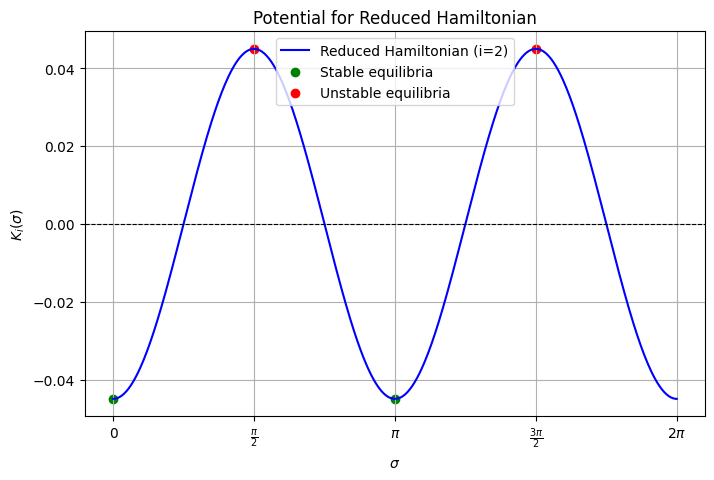

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Constants (example values)
n = 1                 # Orbital frequency (normalized)
B_A_ratio = 0.06      # (B - A) / C ratio (example: Mimas)
e = 0.02              # Orbital eccentricity (example: Mimas)

# Resonance-specific factor (arbitrary choice of i = 2)
i = 2
f_i = lambda e: -e / 2 if i == 1 else (1 - 2.5 * e**2) if i == 2 else (7 * e / 2 if i == 3 else 17 * e**2 / 2)

# Hamiltonian function
K = lambda sigma: -(3 * n / 4) * B_A_ratio * f_i(e) * np.cos(2 * sigma)

# Sigma values for plotting
sigma = np.linspace(0, 2 * np.pi, 500)

# Compute Hamiltonian values
K_values = K(sigma)

# Find equilibria
stable_points = [0, np.pi]  # Where cos(2*sigma) > 0
unstable_points = [np.pi / 2, 3 * np.pi / 2]  # Where cos(2*sigma) < 0

# Plot
plt.figure(figsize=(8, 5))
plt.plot(sigma, K_values, label=f"Reduced Hamiltonian (i={i})", color="blue")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)

# Mark equilibria
plt.scatter(stable_points, K(np.array(stable_points)), color="green", label="Stable equilibria")
plt.scatter(unstable_points, K(np.array(unstable_points)), color="red", label="Unstable equilibria")

# Add labels and legend
plt.title("Potential for Reduced Hamiltonian")
plt.xlabel(r"$\sigma$")
plt.ylabel(r"$K_i(\sigma)$")
plt.xticks(ticks=[0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi],
           labels=["0", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3\pi}{2}$", r"$2\pi$"])
plt.legend()
plt.grid()
plt.show()


# Widths

In [2]:
import numpy as np

# Constants for the bodies
bodies = {
    "Mercury": {"e": 0.21, "B_A_C_ratio": 9.4e-5},
    "Mimas": {"e": 0.02, "B_A_C_ratio": 0.06},
    "Hyperion": {"e": 0.1, "B_A_C_ratio": 0.8},
}

# Resonance-specific factors
def f_i(e, i):
    if i == 1:
        return -e / 2
    elif i == 2:
        return 1 - 2.5 * e**2
    elif i == 3:
        return 7 * e / 2
    elif i == 4:
        return 17 / 2 * e**2
    else:
        raise ValueError("Invalid resonance index")

# Compute width of resonance
def resonance_width(B_A_C_ratio, e, i):
    #print(B_A_C_ratio, f_i(e, i))
    return 0.5 * np.sqrt(i**2 + (12 * B_A_C_ratio * f_i(e, i)))

# Resonance indices to consider
resonances = [1, 2, 3, 4]

# Compute widths for each body and resonance
results = {}
for body, params in bodies.items():
    e = params["e"]
    B_A_C_ratio = params["B_A_C_ratio"]
    results[body] = {}
    for i in resonances:
        try:
            width = resonance_width(B_A_C_ratio, e, i)
            results[body][f"Resonance {i}"] = width
        except ValueError:
            results[body][f"Resonance {i}"] = None

# Print results
for body, res in results.items():
    print(f"\n{body}:")
    for resonance, width in res.items():
        print(f"  {resonance}: Width = {width:.4f} (in \u03A3-space)")



Mercury:
  Resonance 1: Width = 0.5000 (in Σ-space)
  Resonance 2: Width = 1.0001 (in Σ-space)
  Resonance 3: Width = 1.5001 (in Σ-space)
  Resonance 4: Width = 2.0000 (in Σ-space)

Mimas:
  Resonance 1: Width = 0.4982 (in Σ-space)
  Resonance 2: Width = 1.0862 (in Σ-space)
  Resonance 3: Width = 1.5042 (in Σ-space)
  Resonance 4: Width = 2.0002 (in Σ-space)

Hyperion:
  Resonance 1: Width = 0.3606 (in Σ-space)
  Resonance 2: Width = 1.8276 (in Σ-space)
  Resonance 3: Width = 1.7578 (in Σ-space)
  Resonance 4: Width = 2.0504 (in Σ-space)
